# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
import pickle



#### 2. Load data
Load the file *ejer_1_data1.mat*. Find the way for loading this kind of file. **scipy.io.loadmat**

In [91]:
mat = loadmat('./data/ejer_1_data1.mat') 

In [92]:
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

In [93]:
mat['y']

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1]], dtype=uint8)

#### 3. Create a DataFrame with the features and target

In [94]:
# crea df

df = pd.DataFrame(mat['X'], columns=['x1', 'x2'])
df['y'] = mat['y'].ravel()

df.head()

,x1,x2,y
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


In [95]:
# info del df

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      51 non-null     float64
 1   x2      51 non-null     float64
 2   y       51 non-null     uint8  
dtypes: float64(2), uint8(1)
memory usage: 999.0 bytes


In [96]:
# describe del df

df.describe()

,x1,x2,y
count,51.000000,51.000000,51.000000
mean,2.268780,3.132512,0.411765
std,0.928531,0.753256,0.497050
min,0.086405,1.617700,0.000000
25%,1.572550,2.636000,0.000000
50%,2.275300,3.070900,0.000000
75%,2.955050,3.531400,1.000000
max,4.015000,4.616200,1.000000


In [97]:
# value counts de las clases normalizado

df.value_counts(normalize=True)

x1        x2      y
1.964300  4.5957  1    0.019608
2.275300  3.8589  1    0.019608
2.978100  4.5651  1    0.019608
2.932000  3.5519  1    0.019608
3.577200  2.8560  1    0.019608
4.015000  3.1937  1    0.019608
3.381400  3.4291  1    0.019608
3.911300  4.1761  1    0.019608
2.782200  4.0431  1    0.019608
2.551800  4.6162  1    0.019608
3.369800  3.9101  1    0.019608
3.104800  3.0709  1    0.019608
1.918200  4.0534  1    0.019608
2.263800  4.3706  1    0.019608
2.655500  3.5008  1    0.019608
3.185500  4.2888  1    0.019608
3.657900  3.8692  1    0.019608
3.911300  3.4291  1    0.019608
3.600200  3.1221  1    0.019608
3.035700  3.3165  1    0.019608
1.584100  3.3575  0    0.019608
2.010300  3.2039  0    0.019608
1.952700  2.7843  0    0.019608
2.275300  2.7127  0    0.019608
2.309900  2.9584  0    0.019608
2.828300  2.6309  0    0.019608
3.047300  2.2931  0    0.019608
2.482700  2.0373  0    0.019608
2.505700  2.3853  0    0.019608
1.872100  2.0577  0    0.019608
2.010300  2.3546  0 

#### 4. Plot a scatterplot with the data

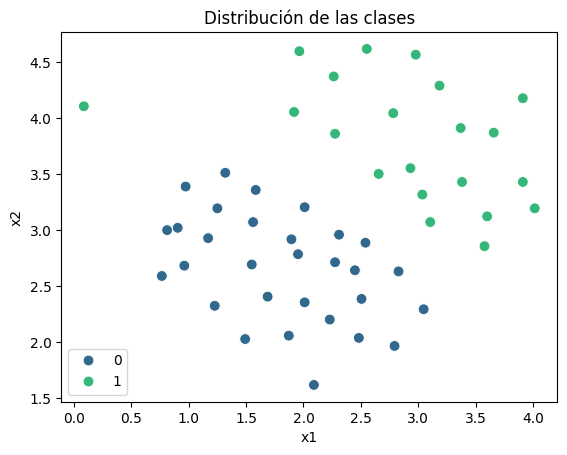

In [98]:


# pinta un scatter con los puntos y el color según la y
# pon la leyenda abajo a la izquierda

sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette='viridis', s=60)
plt.legend(loc='lower left')
plt.title('Distribución de las clases')
plt.show()

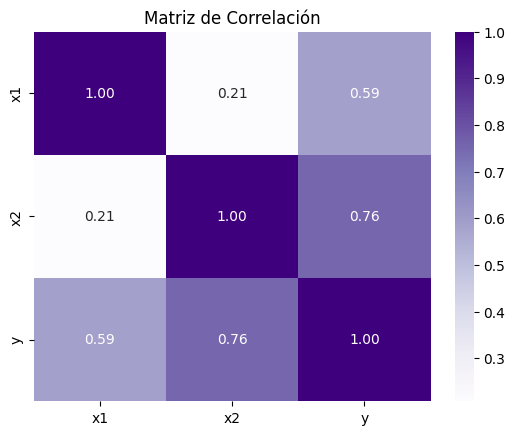

In [99]:
sns.heatmap(df.corr(), annot=True, cmap='Purples', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

Notice that there is one outlier positive example that sits apart from the others.  The classes are still linearly separable but it's a very tight fit.  We're going to train a linear support vector machine to learn the class boundary.

#### 5. LinearSVC
Declare a Linear SVC with the hyperparamenters:

```Python
LinearSVC(C=1, loss='hinge', max_iter=10000)
```

In [100]:
X = df[['x1', 'x2']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X train: {X_train_scaled.shape}")
print(f"X test:  {X_test_scaled.shape}")

X train: (40, 2)
X test:  (11, 2)


In [101]:
svc_1 = SVC(kernel='linear', C=1, probability=True, random_state=42, max_iter=10000)
svc_1.fit(X_train_scaled, y_train)

print(f"Score Train: {svc_1.score(X_train_scaled, y_train):.4f}")
print(f"Score Test:  {svc_1.score(X_test_scaled, y_test):.4f}")

Score Train: 0.9750
Score Test:  1.0000


#### 6. Try the performance (score)
For the first experiment we'll use C=1 and see how it performs.

In [102]:
# no hace falta separar en train y en test por simplicidad
# entrena el modelo con X, y
# calcula el score por defecto del modelo

print(f"Score Train: {svc_1.score(X_train_scaled, y_train):.4f}")
print(f"Score Test:  {svc_1.score(X_test_scaled, y_test):.4f}")

Score Train: 0.9750
Score Test:  1.0000


It appears that it mis-classified the outlier.

#### 7. Increase the value of C until you get a perfect classifier

In [103]:
# equivalente a lo anterior pero subiendo el hiperparámetro C
# C > 500 --> score train: 1.00

svc_2 = SVC(kernel='linear', C=600, probability=True, random_state=42, max_iter=10000)
svc_2.fit(X_train_scaled, y_train)

print(f"Score Train: {svc_2.score(X_train_scaled, y_train):.4f}")
print(f"Score Test:  {svc_2.score(X_test_scaled, y_test):.4f}")

Score Train: 1.0000
Score Test:  1.0000


This time we got a perfect classification of the training data, however by increasing the value of C we've created a decision boundary that is no longer a natural fit for the data.  We can visualize this by looking at the confidence level for each class prediction, which is a function of the point's distance from the hyperplane.

#### 8. Plot Decission Function
Get the `decision_function()` output for the first model. Plot a scatterplot with X1, X2 and a range of colors based on `decision_function()`

In [104]:
# obtén la función de decisión del modelo

decision_vals = svc_1.decision_function(X_train_scaled)


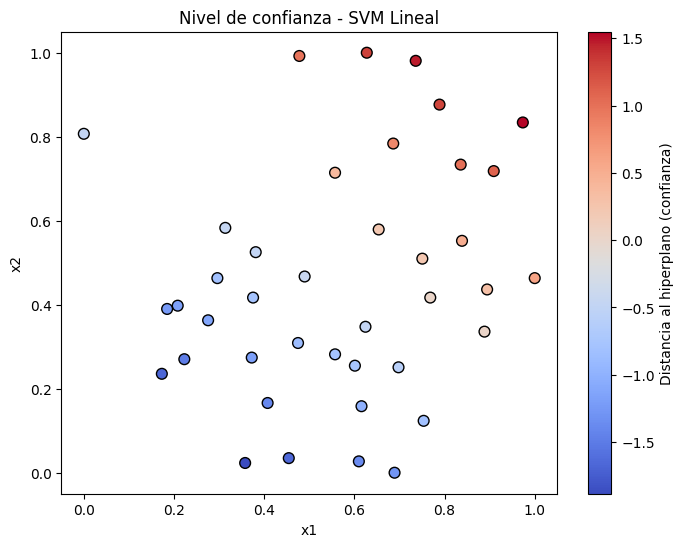

In [105]:

# usa un scatter para pintar los puntos, usa en el parámetro c del scatterplot la función de decisión
# el color puede ser "coolwarm"


plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], 
                      c=decision_vals, cmap='coolwarm', s=60, edgecolors='k')
plt.colorbar(scatter, label='Distancia al hiperplano (confianza)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Nivel de confianza - SVM Lineal')
plt.show()

#### 9. Do the same with the second model

In [106]:
# equivalente pero con el segundo modelo
decision_vals_2 = svc_2.decision_function(X_train_scaled)



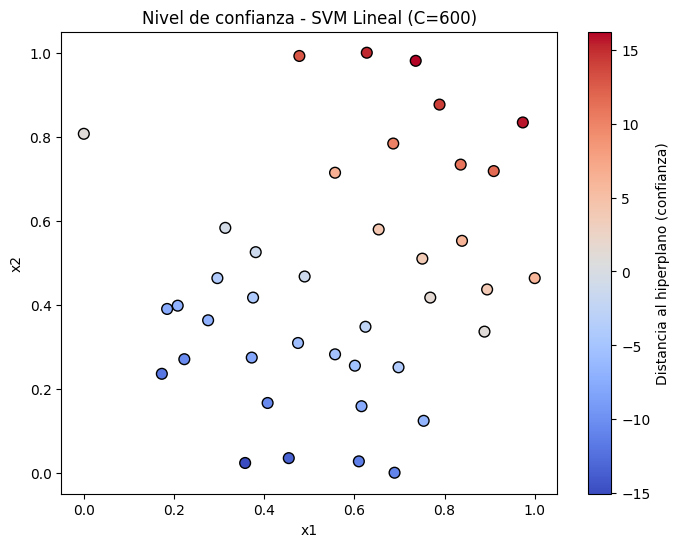

In [107]:
# equivalente con el segundo modelo

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], 
                      c=decision_vals_2, cmap='coolwarm', s=60, edgecolors='k')
plt.colorbar(scatter, label='Distancia al hiperplano (confianza)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Nivel de confianza - SVM Lineal (C=600)')
plt.show()

y = ax1 + bx2 + c

0 = ax1 + bx2 + c

x2 = -ax1/b - c/b

In [108]:
# coeficientes del segundo modelo
# intercept del segundo modelo


a = svc_2.coef_[0][0]
b = svc_2.coef_[0][1]
c = svc_2.intercept_[0]

In [109]:
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

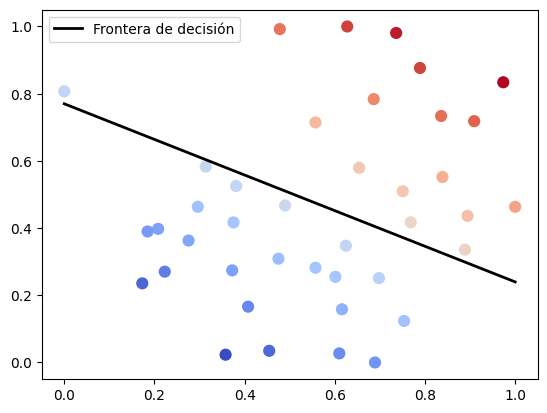

In [110]:


# pinta los puntos con su nivel de confianza
# añade la recta que es la frontera de separación

x_points = np.linspace(X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max(), 100)
y_points = -(a / b) * x_points - (c / b)

plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=decision_vals, cmap='coolwarm', s=60)
plt.plot(x_points, y_points, color='black', linewidth=2, label='Frontera de decisión')
plt.legend()
plt.show()

In [111]:
a = svc_1.coef_[0][0]
b = svc_1.coef_[0][1]
c = svc_1.intercept_
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

Score Train (C=100): 1.0000
Score Test  (C=100): 1.0000


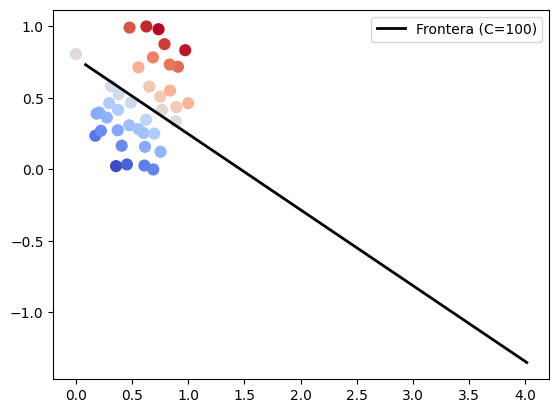

In [112]:
# equivalente con el modelo 1

svc_2 = SVC(kernel='linear', C=10000, probability=True, random_state=42)
svc_2.fit(X_train_scaled, y_train)

print(f"Score Train (C=100): {svc_2.score(X_train_scaled, y_train):.4f}")
print(f"Score Test  (C=100): {svc_2.score(X_test_scaled, y_test):.4f}")

a2, b2, c2 = svc_2.coef_[0][0], svc_2.coef_[0][1], svc_2.intercept_[0]
y_points_2 = -(a2 / b2) * x_points - (c2 / b2)
decision_vals_2 = svc_2.decision_function(X_train_scaled)

plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=decision_vals_2, cmap='coolwarm', s=60)
plt.plot(x_points, y_points_2, color='black', linewidth=2, label='Frontera (C=100)')
plt.legend()
plt.show()

Now we're going to move from a linear SVM to one that's capable of non-linear classification using kernels.  We're first tasked with implementing a gaussian kernel function.  Although scikit-learn has a gaussian kernel built in, for transparency we'll implement one from scratch.

## Exercise 2

That result matches the expected value from the exercise.  Next we're going to examine another data set, this time with a non-linear decision boundary.

#### 1. Load the data `ejer_1_data2.mat`

In [113]:
# descarga los datos y mira sus claves

mat_2 = loadmat('./data/ejer_1_data2.mat') 

mat_2.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

#### 2. Create a DataFrame with the features and target

In [114]:
# crea el df
# muestra su head

X = mat_2['X']
y = mat_2['y'].ravel() 
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['y'] = y


In [115]:
# la info del df

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      863 non-null    float64
 1   x2      863 non-null    float64
 2   y       863 non-null    uint8  
dtypes: float64(2), uint8(1)
memory usage: 14.5 KB


In [116]:
# describe del df

df.describe()

,x1,x2,y
count,863.000000,863.000000,863.000000
mean,0.503414,0.694304,0.556199
std,0.254967,0.158884,0.497120
min,0.044931,0.402632,0.000000
25%,0.292627,0.557018,0.000000
50%,0.512673,0.693713,1.000000
75%,0.699309,0.830409,1.000000
max,0.998848,0.988596,1.000000


#### 3. Plot a scatterplot with the data

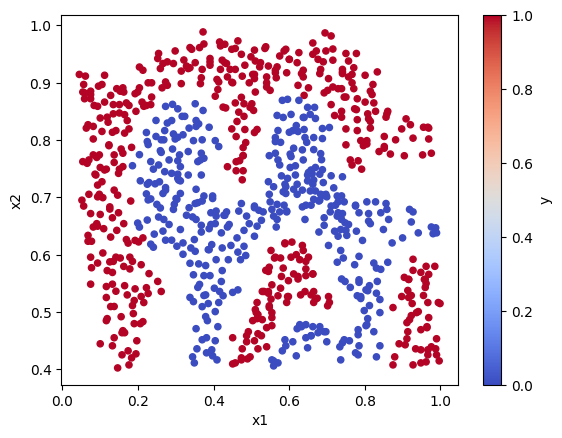

In [117]:
# scatterplot y en hue la y

df.plot.scatter(x='x1', y='x2', c='y', cmap='coolwarm')
plt.show()

In [118]:
seed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (690, 2)
X_test shape: (173, 2)
y_train shape: (690,)
y_test shape: (173,)


For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

Score con C=1: 0.4971


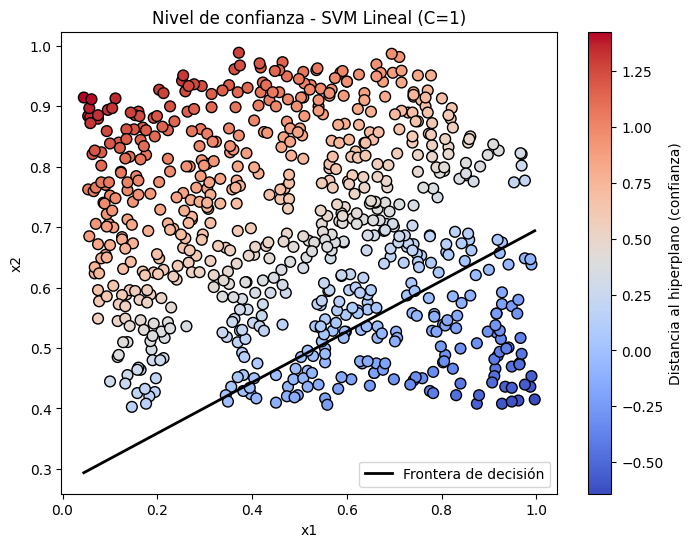

In [119]:
# haz un svc con C = 1, loss = "hinge" y max_iter = 10000
# entrénalo y calcula su score por defecto

svc_3 = SVC(C=1, kernel='linear', max_iter=10000)
svc_3.fit(X_train, y_train)
print(f"Score con C=1: {svc_3.score(X_test, y_test):.4f}")


a = svc_3.coef_[0][0]
b = svc_3.coef_[0][1]
c = svc_3.intercept_
x_points = df['x1'].sort_values()
y_points = -a/b * x_points - c/b

# saca el nivel de confianza
# pinta un scatter con ese nivel de confianza y color "coolwarm"
# pinta la frontera de separación de las clases


decision_vals = svc_3.decision_function(X_train)


plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train[:, 0], X_train[:, 1], 
                      c=decision_vals, cmap='coolwarm', s=60, edgecolors='k')
plt.colorbar(scatter, label='Distancia al hiperplano (confianza)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Nivel de confianza - SVM Lineal (C=1)')


a = svc_3.coef_[0][0] 
b = svc_3.coef_[0][1] 
c = svc_3.intercept_[0] 


x_points = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)
y_points = -(a / b) * x_points - (c / b)

plt.plot(x_points, y_points, color='black', linewidth=2, label='Frontera de decisión')
plt.legend()
plt.show()


#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [120]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svc_4 = SVC(C=100, gamma=10, probability=True)
svc_4.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",10
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [121]:
print(f"Score Train: {svc_4.score(X_train_scaled, y_train):.4f}")
print(f"Score Test:  {svc_4.score(X_test_scaled, y_test):.4f}")

Score Train: 0.9884
Score Test:  0.9942


#### 5. Fit the classifier and get the score

In [123]:
print(f"Score Train: {svc_4.score(X_train_scaled, y_train):.4f}")
print(f"Score Test:  {svc_4.score(X_test_scaled, y_test):.4f}")

Score Train: 0.9884
Score Test:  0.9942


#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [125]:
# pista: tienes que obtener la probabilidad de ser 0

y_pred_proba = svc_4.predict_proba(X_test_scaled)
prob_clase_0 = y_pred_proba[:, 0]
print("Probabilidades de ser clase 0:", prob_clase_0[:10])

Probabilidades de ser clase 0: [6.37350196e-06 6.66747144e-02 3.00000090e-14 9.99353546e-01
 9.99990466e-01 3.31085980e-10 9.99695222e-01 9.86132101e-01
 9.99186889e-01 3.40909721e-11]


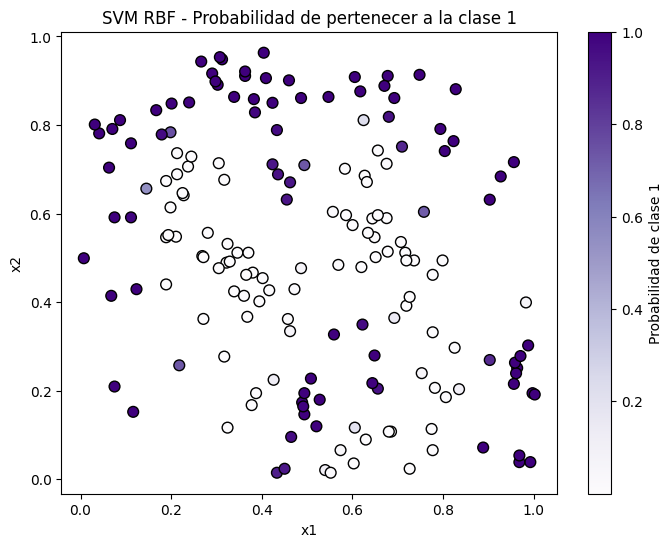

In [128]:
# haz un scatter para los puntos y pon el color según la probabilidad de ser 1

prob_clase_1 = y_pred_proba[:, 1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1],
                      c=prob_clase_1, cmap='Purples', s=60, edgecolors='k')
plt.colorbar(scatter, label='Probabilidad de clase 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('SVM RBF - Probabilidad de pertenecer a la clase 1')
plt.show()

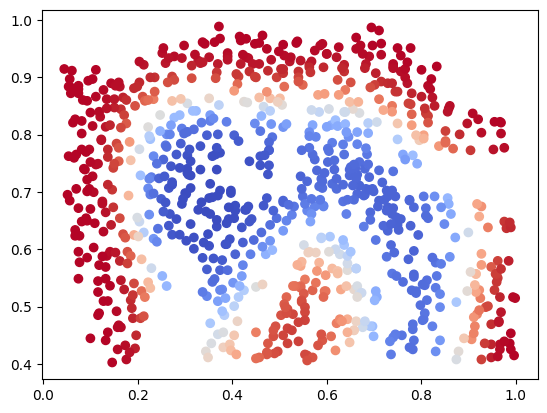

In [129]:
svc_5 = SVC(C=1, gamma=10, probability=True)
svc_5.fit(X, y)
svc_5.score(X, y)
y_pred_proba = svc_5.predict_proba(X)
plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:,1], cmap="coolwarm")

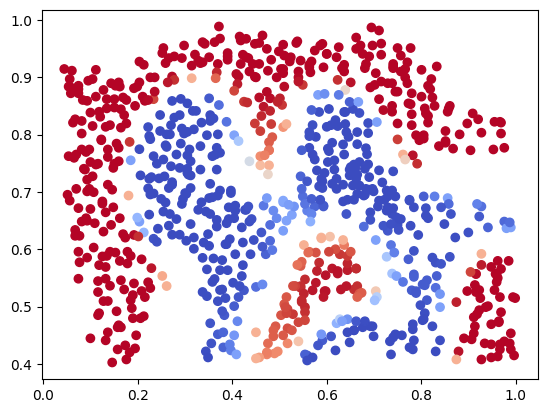

In [130]:
svc_6 = SVC(C=10000, gamma=10, probability=True)
# equivalente

svc_6.fit(X, y)
svc_6.score(X, y)
y_pred_proba = svc_6.predict_proba(X)
plt.scatter(df['x1'], df['x2'], c=y_pred_proba[:,1], cmap="coolwarm")

In [131]:

# importa train_test_split y GridSearchCV
# divide en train y en test con semilla de 42 y 20% para el test

seed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")

X_train: (690, 2), X_test: (173, 2)


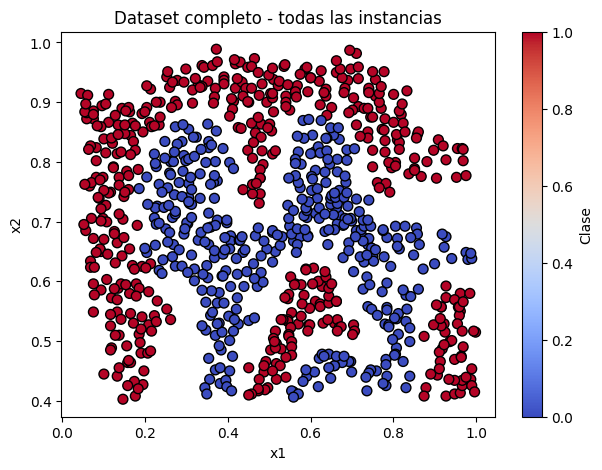

In [132]:

# haz un scatter con todo X, el color viene de y y el color es "coolwarm"

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=50, edgecolors='k')
plt.colorbar(label='Clase')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Dataset completo - todas las instancias')
plt.show()

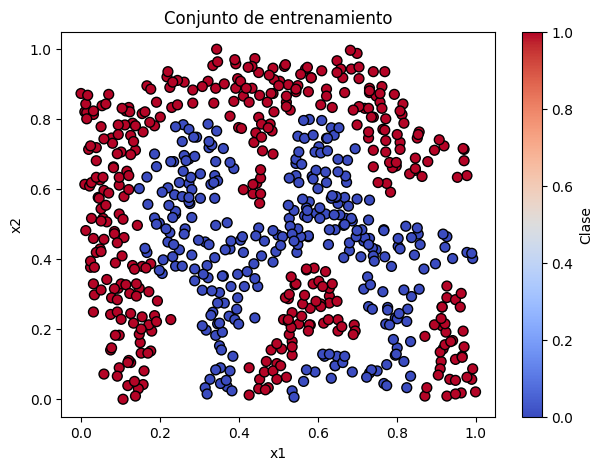

In [133]:
# equivalente con X train

plt.figure(figsize=(7, 5))
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='coolwarm', s=50, edgecolors='k')
plt.colorbar(label='Clase')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Conjunto de entrenamiento')
plt.show()

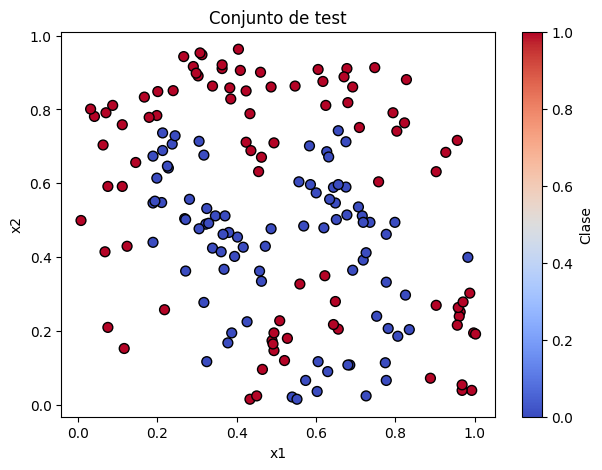

In [134]:
# equivalente con X test

plt.figure(figsize=(7, 5))
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, cmap='coolwarm', s=50, edgecolors='k')
plt.colorbar(label='Clase')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Conjunto de test')
plt.show()

In [135]:
# hiperparámetros: kernel rbf, kernel polynomial, C puede valer 1, 10, 50, 100

# haz un gridsearchcv con 5 folds, scoring accuracy y verbose 2, entrénalo con train
param_grid = {
    'kernel': ['rbf', 'poly'],
    'C': [1, 10, 50, 100]
}

gs = GridSearchCV(SVC(probability=True), param_grid, cv=5, scoring='accuracy', verbose=2)
gs.fit(X_train_scaled, y_train)

print(gs.best_estimator_)
print(gs.best_params_)
print(gs.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ....................................C=1, kernel=rbf; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=1, kernel=poly; total time=   0.0s
[CV] END ...................................C=10, kernel=rbf; total time=   0.0s
[CV] END ...................................C=10,

In [137]:
# mira el score en test

print(f"Score en Test: {gs.score(X_test_scaled, y_test):.4f}")


Score en Test: 0.9711


#### 5. Fit the classifier and get the score

In [138]:
# usa pickle y guarda el estimador GridsearchCV en un archivo

with open('gs_svm_model.pkl', 'wb') as f:
    pickle.dump(gs, f)
print("Modelo guardado como 'gs_svm_model.pkl'")

Modelo guardado como 'gs_svm_model.pkl'


In [139]:
# lee usando pickle el archivo

with open('gs_svm_model.pkl', 'rb') as f:
    modelo_importado = pickle.load(f)
print("Modelo cargado correctamente")

Modelo cargado correctamente


In [140]:
modelo_importado

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probability=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 10, ...], 'kernel': ['rbf', 'poly']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and

In [141]:
# predice [1,3] 

punto = np.array([[1, 3]])
punto_scaled = scaler.transform(punto)
pred = modelo_importado.predict(punto_scaled)
print(f"Predicción para [1, 3]: clase {pred[0]}")

Predicción para [1, 3]: clase 1


In [142]:


# Obtén las probabilidades de ser 1 en test

best_model = gs.best_estimator_
best_model.fit(X_train_scaled, y_train)
prob_test = best_model.predict_proba(X_test_scaled)[:, 1]
print("Primeras 5 probabilidades de clase 1:", prob_test[:5])

Primeras 5 probabilidades de clase 1: [9.92703215e-01 6.19410968e-01 1.00000000e+00 4.21803721e-03
 3.06566086e-05]


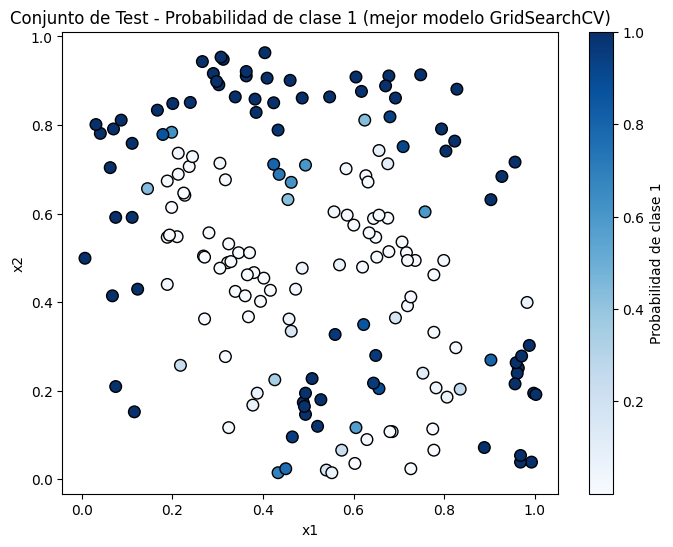

In [143]:
# haz un scatterplot y pinta esos puntos de test con sus probabilidades de ser 1

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1],
                      c=prob_test, cmap='Blues', s=70, edgecolors='k')
plt.colorbar(scatter, label='Probabilidad de clase 1')
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Conjunto de Test - Probabilidad de clase 1 (mejor modelo GridSearchCV)')
plt.show()

In [146]:
# EXTRA

# usa pipeline y PolynomialFeatures
# prueba grados de 2 a 6
# el hiperparámetro C del svc entre -1 y 2, 5 valor espaciados logarítmicamente
# 5 folds
# scoring accuracy
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', MinMaxScaler()),
    ('svc', SVC(probability=True))
])

param_grid_pipe = {
    'poly__degree': [2, 3, 4, 5, 6],
    'svc__C': np.logspace(-1, 2, 5)   # 5 valores log entre 0.1 y 100
}

gs = GridSearchCV(pipe, param_grid_pipe, cv=5, scoring='accuracy', verbose=1)
gs.fit(X_train, y_train)

print('Best Estimator')
print(gs.best_estimator_)
print('Best Params')
print(gs.best_params_)
print('Best Score')
print(gs.best_score_)

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)
final_model.score(X_test, y_test)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Estimator
Pipeline(steps=[('poly', PolynomialFeatures(degree=4)),
                ('scaler', MinMaxScaler()),
                ('svc', SVC(C=np.float64(100.0), probability=True))])
Best Params
{'poly__degree': 4, 'svc__C': np.float64(100.0)}
Best Score
0.9434782608695652


0.9421965317919075

In [148]:
# con pipelines y GridSearchCV
# polynomial puede ser grado 2, 3 o Ninguno
# C del svc espaciado logarítmico entre -1 y 2, 5 valores
# el kernel del svc lineal o gaussiano

# 5 folds, scoring accuracy, verbose 2

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

pipe2 = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', MinMaxScaler()),
    ('svc', SVC(probability=True))
])

# polynomial grado 2, 3 o ninguno (grado 1 = identidad)
# C espaciado logarítmico entre -1 y 2 (5 valores: ~0.1, 0.32, 1, 3.16, 10, 31.6, 100)
# kernel: lineal o gaussiano (rbf)
param_grid_pipe2 = {
    'poly__degree': [1, 2, 3],     # grado 1 equivale a no polinomio
    'svc__C': np.logspace(-1, 2, 5),
    'svc__kernel': ['linear', 'rbf']
}

gs = GridSearchCV(pipe2, param_grid_pipe2, cv=5, scoring='accuracy', verbose=1)
gs.fit(X_train, y_train)

print('Best Estimator')
print(gs.best_estimator_)
print('Best Params')
print(gs.best_params_)
print('Best Score')
print(gs.best_score_)

final_model = gs.best_estimator_
final_model.fit(X_train, y_train)
final_model.score(X_test, y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Estimator
Pipeline(steps=[('poly', PolynomialFeatures(degree=3)),
                ('scaler', MinMaxScaler()),
                ('svc', SVC(C=np.float64(100.0), probability=True))])
Best Params
{'poly__degree': 3, 'svc__C': np.float64(100.0), 'svc__kernel': 'rbf'}
Best Score
0.9420289855072465


0.9364161849710982